# Comparative Analysis of Deep Learning Models for Retinal OCT Disease Classification

This notebook compares the experimental results obtained from three deep learning architectures applied to retinal OCT disease classification using the Kermany2018 dataset.

The evaluated models are:

- ResNet-50
- EfficientNet-B3
- Vision Transformer

The comparison includes predictive performance metrics such as accuracy, precision, recall, F1-score, and Macro F1-score. In addition, computational aspects such as training time, number of parameters, and convergence behavior are analyzed.

Since the dataset presents class imbalance, special attention is given to Macro F1-score and class-level performance instead of relying only on overall accuracy.

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
INPUT_DIR = "/kaggle/input"

print("Contenido de /kaggle/input:")
for item in os.listdir(INPUT_DIR):
    print("-", item)

Contenido de /kaggle/input:
- datasets


In [10]:
for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    
    for file in files[:10]:
        print(f"{indent}    {file}")
    
    if level >= 3:
        break

input/
    datasets/
        cidreee/
            models-results/
                efficientnetb3_classification_report.csv
                efficientnetb3_metrics_summary.csv
                vit_params_summary.csv
                efficientnetb3_params_summary.csv
                resnet50_params_summary.csv
                vit_classification_report.csv
                resnet50_metrics_summary.csv
                vit_metrics_summary.csv
                resnet50_classification_report.csv


In [11]:
csv_files = []

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("CSV files found:")
for file in csv_files:
    print(file)

CSV files found:
/kaggle/input/datasets/cidreee/models-results/efficientnetb3_classification_report.csv
/kaggle/input/datasets/cidreee/models-results/efficientnetb3_metrics_summary.csv
/kaggle/input/datasets/cidreee/models-results/vit_params_summary.csv
/kaggle/input/datasets/cidreee/models-results/efficientnetb3_params_summary.csv
/kaggle/input/datasets/cidreee/models-results/resnet50_params_summary.csv
/kaggle/input/datasets/cidreee/models-results/vit_classification_report.csv
/kaggle/input/datasets/cidreee/models-results/resnet50_metrics_summary.csv
/kaggle/input/datasets/cidreee/models-results/vit_metrics_summary.csv
/kaggle/input/datasets/cidreee/models-results/resnet50_classification_report.csv


In [12]:
def find_file(filename, search_dir="/kaggle/input"):
    for root, dirs, files in os.walk(search_dir):
        if filename in files:
            return os.path.join(root, filename)
    return None


metrics_files = {
    "ResNet50": find_file("resnet50_metrics_summary.csv"),
    "EfficientNetB3": find_file("efficientnetb3_metrics_summary.csv"),
    "Vision Transformer": find_file("vit_metrics_summary.csv")
}

metrics_files

{'ResNet50': '/kaggle/input/datasets/cidreee/models-results/resnet50_metrics_summary.csv',
 'EfficientNetB3': '/kaggle/input/datasets/cidreee/models-results/efficientnetb3_metrics_summary.csv',
 'Vision Transformer': '/kaggle/input/datasets/cidreee/models-results/vit_metrics_summary.csv'}

In [13]:
metrics_dfs = []

for model_name, file_path in metrics_files.items():
    if file_path is not None:
        df = pd.read_csv(file_path)
        metrics_dfs.append(df)
    else:
        print(f"Archivo no encontrado para {model_name}")

df_metrics = pd.concat(metrics_dfs, ignore_index=True)
df_metrics

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,training_time_seconds,training_time_minutes,epochs_trained
0,ResNet50,0.845642,0.862574,0.696966,0.724614,0.851434,0.845642,0.821647,5095.554561,84.925909,18
1,EfficientNetB3,0.874087,0.842829,0.790063,0.810341,0.868777,0.874087,0.868311,6139.241065,102.320684,20
2,Vision Transformer,0.966336,0.952238,0.950802,0.951515,0.966270,0.966336,0.966300,9191.638943,153.193982,14


In [14]:
selected_columns = [
    "model",
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted",
    "training_time_minutes",
    "epochs_trained"
]

df_metrics_clean = df_metrics[selected_columns].copy()
df_metrics_clean

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,training_time_minutes,epochs_trained
0,ResNet50,0.845642,0.862574,0.696966,0.724614,0.851434,0.845642,0.821647,84.925909,18
1,EfficientNetB3,0.874087,0.842829,0.790063,0.810341,0.868777,0.874087,0.868311,102.320684,20
2,Vision Transformer,0.966336,0.952238,0.950802,0.951515,0.966270,0.966336,0.966300,153.193982,14


In [15]:
df_metrics_clean.to_csv("/kaggle/working/model_performance_comparison.csv", index=False)

In [16]:
params_files = {
    "ResNet50": find_file("resnet50_params_summary.csv"),
    "EfficientNetB3": find_file("efficientnetb3_params_summary.csv"),
    "Vision Transformer": find_file("vit_params_summary.csv")
}

params_files

{'ResNet50': '/kaggle/input/datasets/cidreee/models-results/resnet50_params_summary.csv',
 'EfficientNetB3': '/kaggle/input/datasets/cidreee/models-results/efficientnetb3_params_summary.csv',
 'Vision Transformer': '/kaggle/input/datasets/cidreee/models-results/vit_params_summary.csv'}

In [17]:
params_dfs = []

for model_name, file_path in params_files.items():
    if file_path is not None:
        df = pd.read_csv(file_path)
        params_dfs.append(df)
    else:
        print(f"Archivo no encontrado para {model_name}")

df_params = pd.concat(params_dfs, ignore_index=True)
df_params

,model,total_params,trainable_params,non_trainable_params
0,ResNet50,23595908,8196,23587712.0
1,EfficientNetB3,10789683,6148,10783535.0
2,Vision Transformer,21667204,21667204,0.0


In [18]:
df_params.to_csv("/kaggle/working/model_parameters_comparison.csv", index=False)

In [19]:
df_comparison = pd.merge(
    df_metrics_clean,
    df_params,
    on="model",
    how="left"
)

df_comparison

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,training_time_minutes,epochs_trained,total_params,trainable_params,non_trainable_params
0,ResNet50,0.845642,0.862574,0.696966,0.724614,0.851434,0.845642,0.821647,84.925909,18,23595908,8196,23587712.0
1,EfficientNetB3,0.874087,0.842829,0.790063,0.810341,0.868777,0.874087,0.868311,102.320684,20,10789683,6148,10783535.0
2,Vision Transformer,0.966336,0.952238,0.950802,0.951515,0.966270,0.966336,0.966300,153.193982,14,21667204,21667204,0.0


In [20]:
df_comparison.to_csv("/kaggle/working/final_model_comparison.csv", index=False)

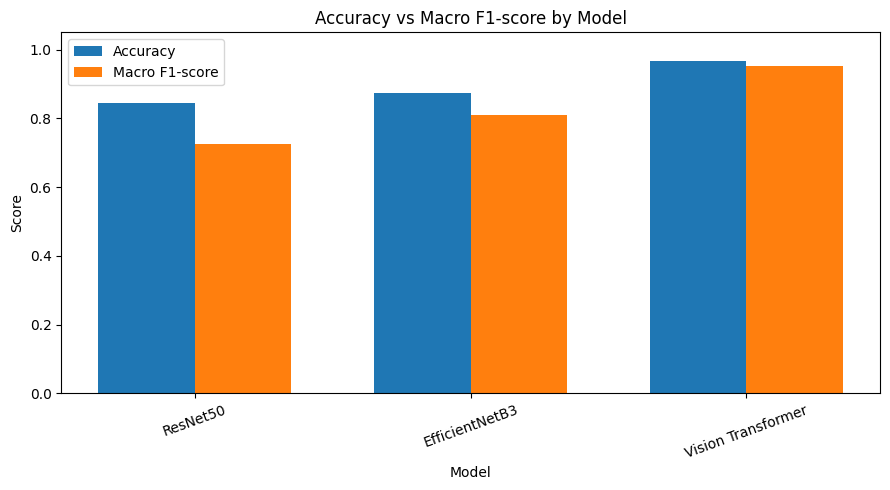

In [21]:
plt.figure(figsize=(9, 5))

x = np.arange(len(df_comparison["model"]))
width = 0.35

plt.bar(x - width/2, df_comparison["accuracy"], width, label="Accuracy")
plt.bar(x + width/2, df_comparison["f1_macro"], width, label="Macro F1-score")

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Accuracy vs Macro F1-score by Model")
plt.xticks(x, df_comparison["model"], rotation=20)
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/accuracy_vs_macro_f1.png", dpi=300)
plt.show()

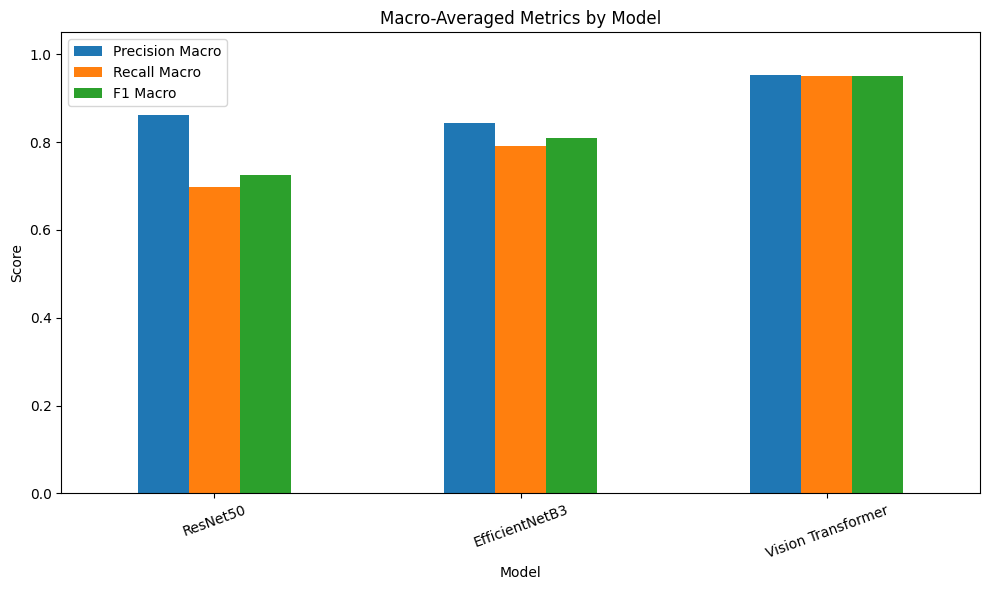

In [22]:
metrics_to_plot = ["precision_macro", "recall_macro", "f1_macro"]

df_plot = df_comparison.set_index("model")[metrics_to_plot]

ax = df_plot.plot(kind="bar", figsize=(10, 6))

plt.title("Macro-Averaged Metrics by Model")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(["Precision Macro", "Recall Macro", "F1 Macro"])
plt.tight_layout()
plt.savefig("/kaggle/working/macro_metrics_comparison.png", dpi=300)
plt.show()

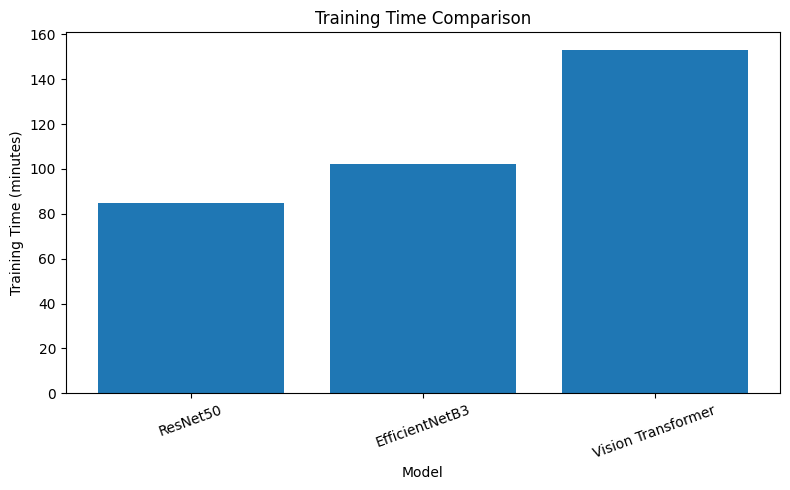

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(df_comparison["model"], df_comparison["training_time_minutes"])
plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time (minutes)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("/kaggle/working/training_time_comparison.png", dpi=300)
plt.show()

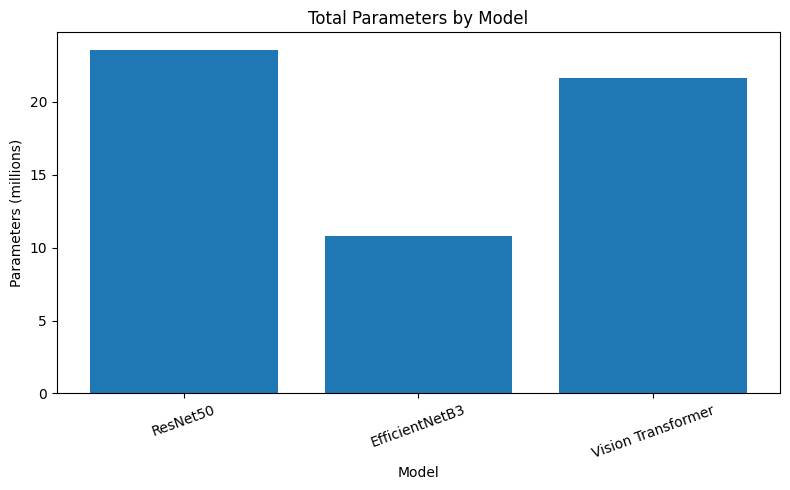

In [25]:
df_comparison["total_params_millions"] = df_comparison["total_params"] / 1_000_000

plt.figure(figsize=(8, 5))

plt.bar(df_comparison["model"], df_comparison["total_params_millions"])
plt.title("Total Parameters by Model")
plt.xlabel("Model")
plt.ylabel("Parameters (millions)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("/kaggle/working/model_parameters_millions_comparison.png", dpi=300)
plt.show()

In [26]:
best_accuracy = df_comparison.loc[df_comparison["accuracy"].idxmax()]
best_macro_f1 = df_comparison.loc[df_comparison["f1_macro"].idxmax()]
fastest_model = df_comparison.loc[df_comparison["training_time_minutes"].idxmin()]

print("Best model by Accuracy:")
print(best_accuracy[["model", "accuracy"]])

print("\nBest model by Macro F1-score:")
print(best_macro_f1[["model", "f1_macro"]])

print("\nFastest model:")
print(fastest_model[["model", "training_time_minutes"]])

Best model by Accuracy:
model       Vision Transformer
accuracy              0.966336
Name: 2, dtype: object

Best model by Macro F1-score:
model       Vision Transformer
f1_macro              0.951515
Name: 2, dtype: object

Fastest model:
model                     ResNet50
training_time_minutes    84.925909
Name: 0, dtype: object


In [27]:
summary = {
    "best_accuracy_model": best_accuracy["model"],
    "best_accuracy": best_accuracy["accuracy"],
    "best_macro_f1_model": best_macro_f1["model"],
    "best_macro_f1": best_macro_f1["f1_macro"],
    "fastest_model": fastest_model["model"],
    "fastest_training_time_minutes": fastest_model["training_time_minutes"]
}

df_summary = pd.DataFrame([summary])
df_summary.to_csv("/kaggle/working/final_comparison_summary.csv", index=False)

df_summary

,best_accuracy_model,best_accuracy,best_macro_f1_model,best_macro_f1,fastest_model,fastest_training_time_minutes
0,Vision Transformer,0.966336,Vision Transformer,0.951515,ResNet50,84.925909


## Comparative Discussion

The three models were compared using accuracy, macro-averaged precision, macro-averaged recall, Macro F1-score, training time, and number of parameters. Macro F1-score was considered the most relevant metric because the dataset presents class imbalance, and this metric evaluates all classes with equal importance.

The results show that all models achieved competitive performance for retinal OCT disease classification. However, differences were observed in terms of predictive performance and computational cost. The best model should not be selected only based on accuracy, but also considering Macro F1-score, training time, convergence behavior, and model complexity.

Classes with fewer samples, such as DRUSEN and DME, are especially important for the analysis because they reveal whether the models generalize beyond the majority classes. Therefore, confusion matrices and per-class F1-scores should be analyzed to determine if each architecture performs consistently across all retinal disease categories.